# Deep Water problem GPU version

In [14]:
import Pkg; Pkg.add("NBInclude")

   Resolving package versions...
   Installed NBInclude ─ v2.4.0
      Compat entries added for NBInclude
    Updating `~/JuliaNantes2019/Project.toml`
  [0db19996] + NBInclude v2.4.0
    Updating `~/JuliaNantes2019/Manifest.toml`
  [0db19996] + NBInclude v2.4.0
  [b85f4697] + SoftGlobalScope v1.1.0
Precompiling packages...
   1256.9 ms  ✓ SoftGlobalScope
   1222.0 ms  ✓ NBInclude
  2 dependencies successfully precompiled in 5 seconds. 263 already precompiled.


Progress: 100%|█████████████████████████████████████████| Time: 0:00:14
Progress: 100%|█████████████████████████████████████████| Time: 0:00:13
[ Info: Saved animation to /home/pnavaro/JuliaNantes2019/anim_Matsuno.gif


Plots.AnimatedGif("/home/pnavaro/JuliaNantes2019/anim_Matsuno.gif")
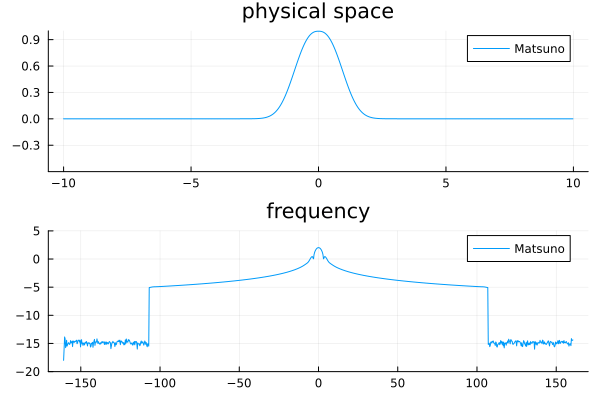

In [15]:
using NBInclude
@nbinclude("04.DeepWaterProblem.ipynb")

In [16]:
using CUDA
CUDA.name(CuDevice(0))

"Tesla V100S-PCIE-32GB"

In [17]:
using CUDA.CUFFT
CUDA.allowscalar(false)

In [18]:
using BenchmarkTools

In [19]:
function matsuno!(h, u, p, pinv, Γ, ϵ, Dx, H, Π⅔, unew, hnew, I₀, I₁, I₂, I₃)
    
    @. unew = Γ * h
    pinv * unew
    
    @. hnew = Dx * h
    @. I₁   = hnew
    pinv * I₁
    
    @. I₁ = unew * I₁
    p * I₁
    
    @. I₁ = I₁ * ϵ * Π⅔ - hnew
    @. hnew = h
    pinv * hnew
    
    @. unew = u
    pinv * unew
    
    @. I₃ = hnew * unew
    p * I₃
    
    @. h = H * u
    @. I₂ = Γ * u 
    pinv * I₂
    
    @. hnew = I₂ * hnew 
    p * hnew
    
    @. h = h - (I₃ * Dx + hnew * H) * ϵ * Π⅔
    @. unew = unew^2  
    p * unew
    
    @. u = I₁ - unew * Dx * ϵ/2 * Π⅔
    
end

matsuno! (generic function with 1 method)

In [20]:
function loop_over_time( h, u, N, Nt, dt, ϵ, k, kmax )
    
    Uhat = CuArray{ComplexF64,2}(undef, (N,2))
    dU   = CuArray{ComplexF64,2}(undef, (N,2))

    data = zeros(ComplexF64,(N,2,Nt))
    
    Γ   = CuArray(abs.(k))
    Dx  = CuArray(1im * k)        # Differentiation
    H   = CuArray(-1im * sign.(k)) # Hilbert transform
    Π⅔  = CuArray(abs.(k) .< kmax * 2/3) # Dealiasing low-pass filter

    hnew = CuArray{ComplexF64}(undef, N)
    unew = CuArray{ComplexF64}(undef, N)
    
    I₀ = CuArray{ComplexF64}(undef,N)
    I₁ = CuArray{ComplexF64}(undef,N)
    I₂ = CuArray{ComplexF64}(undef,N)
    I₃ = CuArray{ComplexF64}(undef,N)
    
    p    = plan_fft!(h)
    pinv = plan_ifft!(h)
    
    p * h
    p * u
    
    h .= Π⅔ .* h 
    u .= Π⅔ .* u
    
    U = CuArray(hcat(h,u))
    
    for j in 1:Nt
        
        Uhat .= U
        matsuno!( view(Uhat,:,1), view(Uhat,:,2), p, pinv, 
                  Γ, ϵ, Dx, H, Π⅔, unew, hnew, I₀, I₁, I₂, I₃ )
    
        dU   .= Uhat
        Uhat .= U .+ dt/2 .* Uhat
    
        matsuno!(view(Uhat,:,1), view(Uhat,:,2), p, pinv,
                 Γ, ϵ, Dx, H, Π⅔, unew, hnew, I₀, I₁, I₂, I₃  )
    
        dU   .+= 2 .* Uhat
        Uhat .= U .+ dt/2 .* Uhat
    
        matsuno!( view(Uhat,:,1), view(Uhat,:,2), p, pinv, 
                 Γ, ϵ, Dx, H, Π⅔, unew, hnew, I₀, I₁, I₂, I₃ )
    
        dU   .+= 2 .* Uhat
        Uhat .= U .+ dt .* Uhat
        
        matsuno!( view(Uhat,:,1), view(Uhat,:,2), p, pinv, 
                  Γ, ϵ, Dx, H, Π⅔, unew, hnew, I₀, I₁, I₂, I₃ )
    
        dU .+= Uhat
        U  .+= dt/6 .* dU
             
        data[:,:,j] .= collect(U)
        
    end
    data
end

loop_over_time (generic function with 1 method)

In [21]:
function main_gpu(N :: Int64; animation=true)

    param = ( ϵ  = 1/2,
              N  = N,
              L  = 10.,
              T  = 5.,
              dt = 0.001 )
    
    mesh    = Mesh(param)
    times   = Times(param.dt, param.T)
    init    = BellCurve(param,2.5)
    model   = Matsuno(param)
    mesh    = Mesh(param)
    
    h  = CuArray(init.h)
    u  = CuArray(init.u)
    
    data = loop_over_time( h, u, mesh.N, times.Nt, cu(param.dt), cu(param.ϵ), mesh.k, mesh.kmax )

    if animation
        create_animation( mesh, times, model, data )
    end

end

main_gpu (generic function with 1 method)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:11


 50.920960 seconds (51.25 M allocations: 3.354 GiB, 1.78% gc time, 62.18% compilation time: 2% of which was recompilation)


[ Info: Saved animation to /home/pnavaro/JuliaNantes2019/anim_Matsuno.gif


Plots.AnimatedGif("/home/pnavaro/JuliaNantes2019/anim_Matsuno.gif")
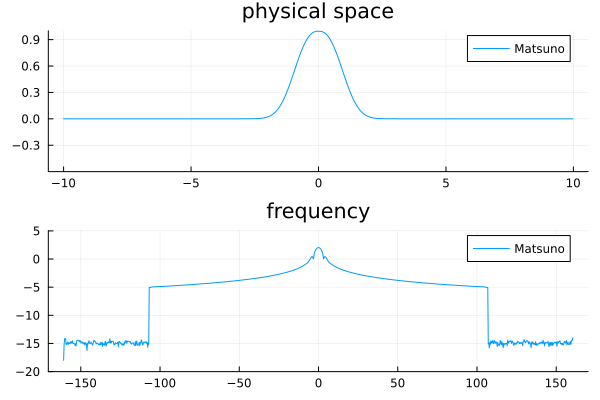

In [22]:
@time main_gpu( 2^10; animation=true)

In [23]:
@time main_gpu( 2^14; animation=false)

 14.365352 seconds (17.42 M allocations: 7.837 GiB, 4.80% gc time, 1.34% compilation time)


In [24]:
@time main_cpu( 2^14; animation=false)

Progress: 100%|█████████████████████████████████████████| Time: 0:01:32


 93.971384 seconds (12.98 M allocations: 3.317 GiB, 1.07% gc time, 0.07% compilation time)
